# PINN Spectral Bias Analysis

Trains a physics-informed neural network (PINN) on a forced first-order ODE with
multiple frequency components and analyses spectral bias via FFT of training
snapshots and the Neural Tangent Kernel.

In [21]:
from pathlib import Path
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from argparse import Namespace
from scipy.integrate import solve_ivp

ROOT = Path().resolve()
while not (ROOT / "src").is_dir():
    if ROOT == ROOT.parent:
        raise RuntimeError(f"Cannot find project root from {Path().resolve()}")
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))
print(f"ROOT = {ROOT}")

from src.PINNs import PINN, PINNConfig, TrainingConfig, TrainingFrame
from src.numerical_solvers import picard_solve
from src.spectral_analysis import compute_fft, compute_ntk, ntk_spectrum

sns.set_theme(style="whitegrid")
torch.manual_seed(42)
np.random.seed(42)

FIGURES_DIR = Path().resolve() / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
print(f"Figures -> {FIGURES_DIR}")

ROOT = /Users/marcogalliani/Projects/PINNs-and-spectral-bias
Figures -> /Users/marcogalliani/Projects/PINNs-and-spectral-bias/examples/spectral-analysis/figures


## ODE definition

In [22]:
class ForcedFirstOrderODE:
    """
    z' = -alpha*z + sum_k A_k sin(2*pi*f_k*t + phi_k)

    Provides two RHS callables:
      rhs_np    -- (t: float, z: ndarray(1,)) -> list[float]           (scipy/Picard)
      rhs_torch -- (t: Tensor(N,1), z: Tensor(N,1)) -> Tensor(N,1)     (PINN)
    """

    def __init__(self, alpha, freqs, amps, phases):
        self.alpha  = alpha
        self.freqs  = list(freqs)
        self.amps   = list(amps)
        self.phases = list(phases)

    def _forcing(self, t, sin_fn):
        return sum(
            A * sin_fn(2 * np.pi * f * t + ph)
            for f, A, ph in zip(self.freqs, self.amps, self.phases)
        )

    def rhs_np(self, t, z):
        return [-self.alpha * z[0] + self._forcing(t, np.sin)]

    def rhs_torch(self, t, z):
        return -self.alpha * z + self._forcing(t, torch.sin)

## Configuration

In [23]:
opt = Namespace()

opt.alpha  = 1.0
opt.freqs  = [1.0, 3.0, 5.0, 10.0]
opt.amps   = [1.0, 1.0, 1.0, 1.0]
opt.phases = [0.0, 0.0, 0.0, 0.0]
opt.y0     = [0.0]

opt.T        = 2.0
opt.N_POINTS = 200

opt.PICARD_ITERS = 20

if torch.cuda.is_available():
    opt.DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    opt.DEVICE = torch.device("mps")
else:
    opt.DEVICE = torch.device("cpu")
print(f"Device: {opt.DEVICE}")

model_cfg = PINNConfig(n_vars=1, width=512, depth=4)

tr_cfg = TrainingConfig(
    n_iter=10_000,
    n_colloc=512,
    lr=1e-3,
    ic_weight=1.0,
    hard_ic=False,
    rec_frq=100,
    save_snapshots=True,
    verbose=True,
    adaptive_weights=True,
    ntk_update_freq=100,
    ntk_n_samples=100,
    ntk_ema=0.9,
)

ode         = ForcedFirstOrderODE(opt.alpha, opt.freqs, opt.amps, opt.phases)
t_eval      = np.linspace(0, opt.T, opt.N_POINTS)
sample_rate = opt.N_POINTS / opt.T

Device: mps


## Reference solution and Picard iterates

In [24]:
print("Reference (RK45)...")
sol_ref = solve_ivp(ode.rhs_np, [0, opt.T], opt.y0, t_eval=t_eval,
                    method="RK45", rtol=1e-9, atol=1e-11)
y_ref = sol_ref.y.T

print(f"Picard ({opt.PICARD_ITERS} iterations)...")
picard_iterates = picard_solve(ode.rhs_np, opt.y0, t_eval, opt.PICARD_ITERS)
y_picard = picard_iterates[-1]

Reference (RK45)...
Picard (20 iterations)...


## PINN training

In [25]:
print(f"PINN ({tr_cfg.n_iter} iters, width={model_cfg.width}, depth={model_cfg.depth})...")
model = PINN(model_cfg).to(opt.DEVICE)

frames = model.fit(
    ode.rhs_torch,
    t_span=(0.0, opt.T),
    y0=opt.y0,
    tr_cfg=tr_cfg,
    t_eval_np=t_eval,
)

with torch.no_grad():
    t_tensor = torch.tensor(t_eval, dtype=torch.float32, device=opt.DEVICE).view(-1, 1)
    y_pinn   = model(t_tensor).cpu().numpy()

PINN (10000 iters, width=512, depth=4)...
  iter      0 | total 1.994e+00 | phys 1.993e+00 | ic 7.589e-04 | w_ic 1.000e+00
  [NTK] iter    100 | ic_weight 1.271e+00  (raw=3.707e+00)
  [NTK] iter    200 | ic_weight 1.625e+00  (raw=4.812e+00)
  [NTK] iter    300 | ic_weight 2.219e+00  (raw=7.566e+00)
  [NTK] iter    400 | ic_weight 2.964e+00  (raw=9.671e+00)
  [NTK] iter    500 | ic_weight 4.270e+00  (raw=1.602e+01)
  [NTK] iter    600 | ic_weight 5.763e+00  (raw=1.920e+01)
  [NTK] iter    700 | ic_weight 7.651e+00  (raw=2.464e+01)
  [NTK] iter    800 | ic_weight 1.012e+01  (raw=3.229e+01)
  [NTK] iter    900 | ic_weight 1.414e+01  (raw=5.038e+01)
  [NTK] iter   1000 | ic_weight 1.666e+01  (raw=3.937e+01)
  [NTK] iter   1100 | ic_weight 2.007e+01  (raw=5.075e+01)
  [NTK] iter   1200 | ic_weight 2.256e+01  (raw=4.491e+01)
  [NTK] iter   1300 | ic_weight 2.497e+01  (raw=4.671e+01)
  [NTK] iter   1400 | ic_weight 2.733e+01  (raw=4.856e+01)
  [NTK] iter   1500 | ic_weight 2.941e+01  (raw=4.8

## Analysis

### Solution

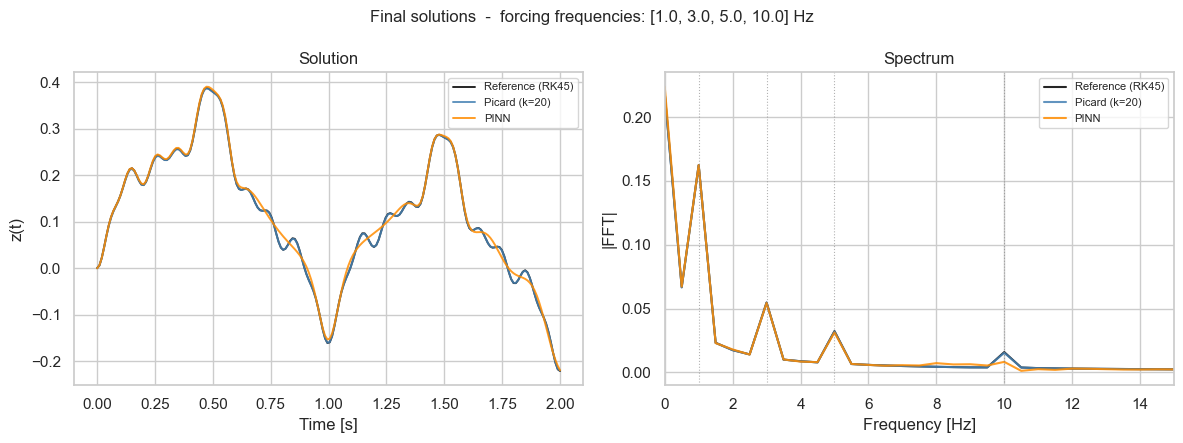

In [26]:
# Solution comparison: time domain + spectrum
solutions = [y_ref, y_picard, y_pinn]
labels    = ["Reference (RK45)", f"Picard (k={opt.PICARD_ITERS})", "PINN"]
colors    = ["black", "steelblue", "darkorange"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle(f"Final solutions  -  forcing frequencies: {opt.freqs} Hz", fontsize=12)

for sol, lab, col in zip(solutions, labels, colors):
    axes[0].plot(t_eval, sol[:, 0], label=lab, color=col, alpha=0.85, linewidth=1.4)
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("z(t)")
axes[0].set_title("Solution")
axes[0].legend(fontsize=8)

for sol, lab, col in zip(solutions, labels, colors):
    frqs, spec = compute_fft(sol[:, 0], sample_rate)
    axes[1].plot(frqs, spec, label=lab, color=col, alpha=0.85)
for f in opt.freqs:
    axes[1].axvline(f, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
axes[1].set_xlim([0, max(opt.freqs) * 1.5])
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("|FFT|")
axes[1].set_title("Spectrum")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "solution_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Learning behaviour

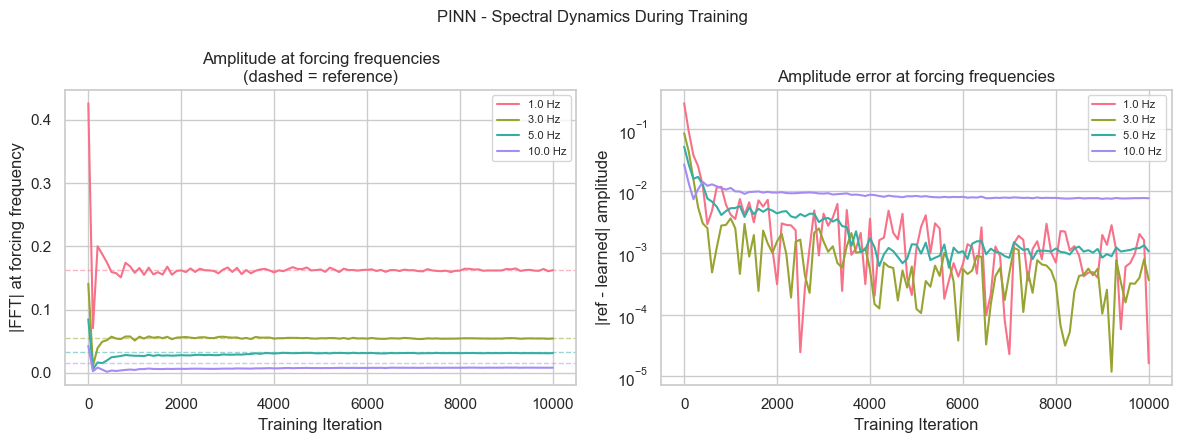

In [27]:
# PINN spectral dynamics during training
palette   = sns.color_palette("husl", len(opt.freqs))
iter_nums = np.asarray([f.iter_num for f in frames])

amp_curves = {f: [] for f in opt.freqs}
for pred in [f.prediction for f in frames]:
    frqs_fft, spec = compute_fft(pred[:, 0], sample_rate)
    for f in opt.freqs:
        amp_curves[f].append(float(spec[np.argmin(np.abs(frqs_fft - f))]))

frqs_ref_fft, spec_ref = compute_fft(y_ref[:, 0], sample_rate)
ref_amps = {f: float(spec_ref[np.argmin(np.abs(frqs_ref_fft - f))]) for f in opt.freqs}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("PINN - Spectral Dynamics During Training", fontsize=12)

ax = axes[0]
for f, col in zip(opt.freqs, palette):
    ax.plot(iter_nums, amp_curves[f], label=f"{f} Hz", color=col)
    ax.axhline(ref_amps[f], color=col, linestyle="--", linewidth=1, alpha=0.5)
ax.set_xlabel("Training Iteration")
ax.set_ylabel("|FFT| at forcing frequency")
ax.set_title("Amplitude at forcing frequencies\n(dashed = reference)")
ax.legend(fontsize=8)

ax = axes[1]
for f, col in zip(opt.freqs, palette):
    errs = [abs(a - ref_amps[f]) for a in amp_curves[f]]
    ax.plot(iter_nums, errs, label=f"{f} Hz", color=col)
ax.set_xlabel("Training Iteration")
ax.set_ylabel("|ref - learned| amplitude")
ax.set_title("Amplitude error at forcing frequencies")
ax.set_yscale("log")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "pinn_spectral_dynamics.png", dpi=150, bbox_inches="tight")
plt.show()

### Residuals

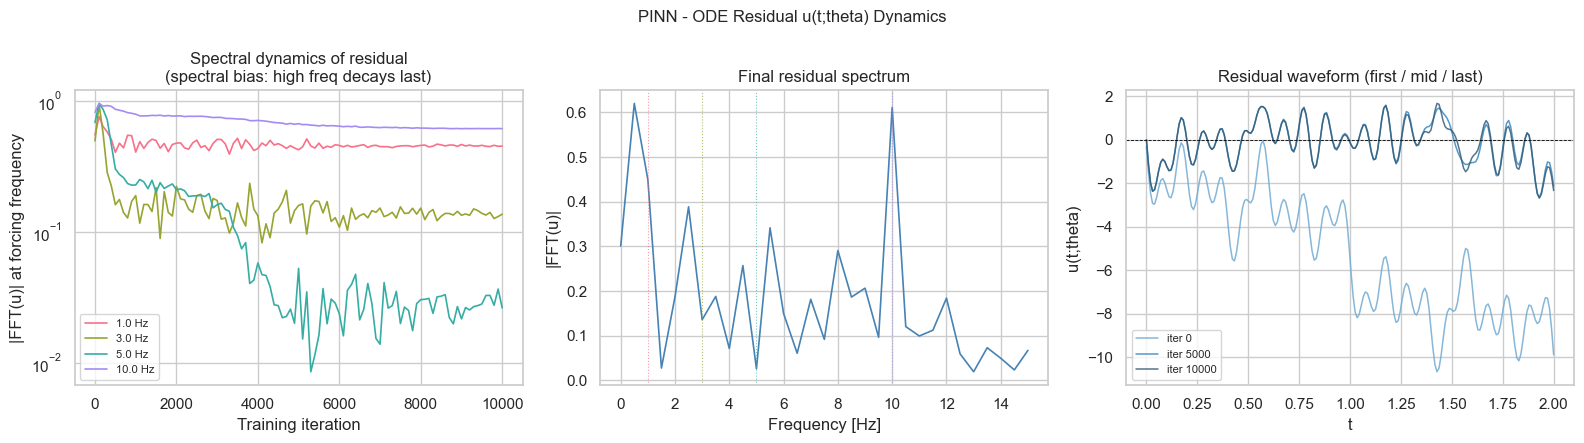

In [28]:
# PINN ODE residual dynamics across training snapshots
residuals = model.compute_residuals(
    frames, ode.rhs_torch, t_eval, opt.y0,
    hard_ic=True, device=opt.DEVICE,
)

valid_r      = [(f.iter_num, r) for f, r in zip(frames, residuals) if r is not None]
iters_r      = np.asarray([v[0] for v in valid_r])
res_list     = [v[1] for v in valid_r]
palette_r    = sns.color_palette("husl", len(opt.freqs))
snap_idx_r   = [0, len(res_list) // 2, len(res_list) - 1]
snap_palette = sns.color_palette("Blues_d", len(snap_idx_r))

amp_curves_r = {f: [] for f in opt.freqs}
for r in res_list:
    frqs_k, spec_k = compute_fft(r[:, 0], sample_rate)
    for f in opt.freqs:
        amp_curves_r[f].append(float(spec_k[np.argmin(np.abs(frqs_k - f))]))

frqs_final_r, spec_final_r = compute_fft(res_list[-1][:, 0], sample_rate)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("PINN - ODE Residual u(t;theta) Dynamics", fontsize=12)

ax = axes[0]
for f, col in zip(opt.freqs, palette_r):
    ax.plot(iters_r, amp_curves_r[f], label=f"{f} Hz", color=col, linewidth=1.2)
ax.set_xlabel("Training iteration")
ax.set_ylabel("|FFT(u)| at forcing frequency")
ax.set_yscale("log")
ax.set_title("Spectral dynamics of residual\n(spectral bias: high freq decays last)")
ax.legend(fontsize=8)

ax = axes[1]
mask = frqs_final_r <= max(opt.freqs) * 1.5
ax.plot(frqs_final_r[mask], spec_final_r[mask], color="steelblue", linewidth=1.2)
for f, col in zip(opt.freqs, palette_r):
    ax.axvline(f, color=col, linestyle=":", linewidth=0.8, alpha=0.7)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("|FFT(u)|")
ax.set_title("Final residual spectrum")

ax = axes[2]
for idx, col in zip(snap_idx_r, snap_palette):
    ax.plot(t_eval, res_list[idx][:, 0], color=col, alpha=0.85, linewidth=1.1,
            label=f"iter {iters_r[idx]}")
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_xlabel("t")
ax.set_ylabel("u(t;theta)")
ax.set_title("Residual waveform (first / mid / last)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "pinn_residual_dynamics.png", dpi=150, bbox_inches="tight")
plt.show()

### Neural Tangent Kernel

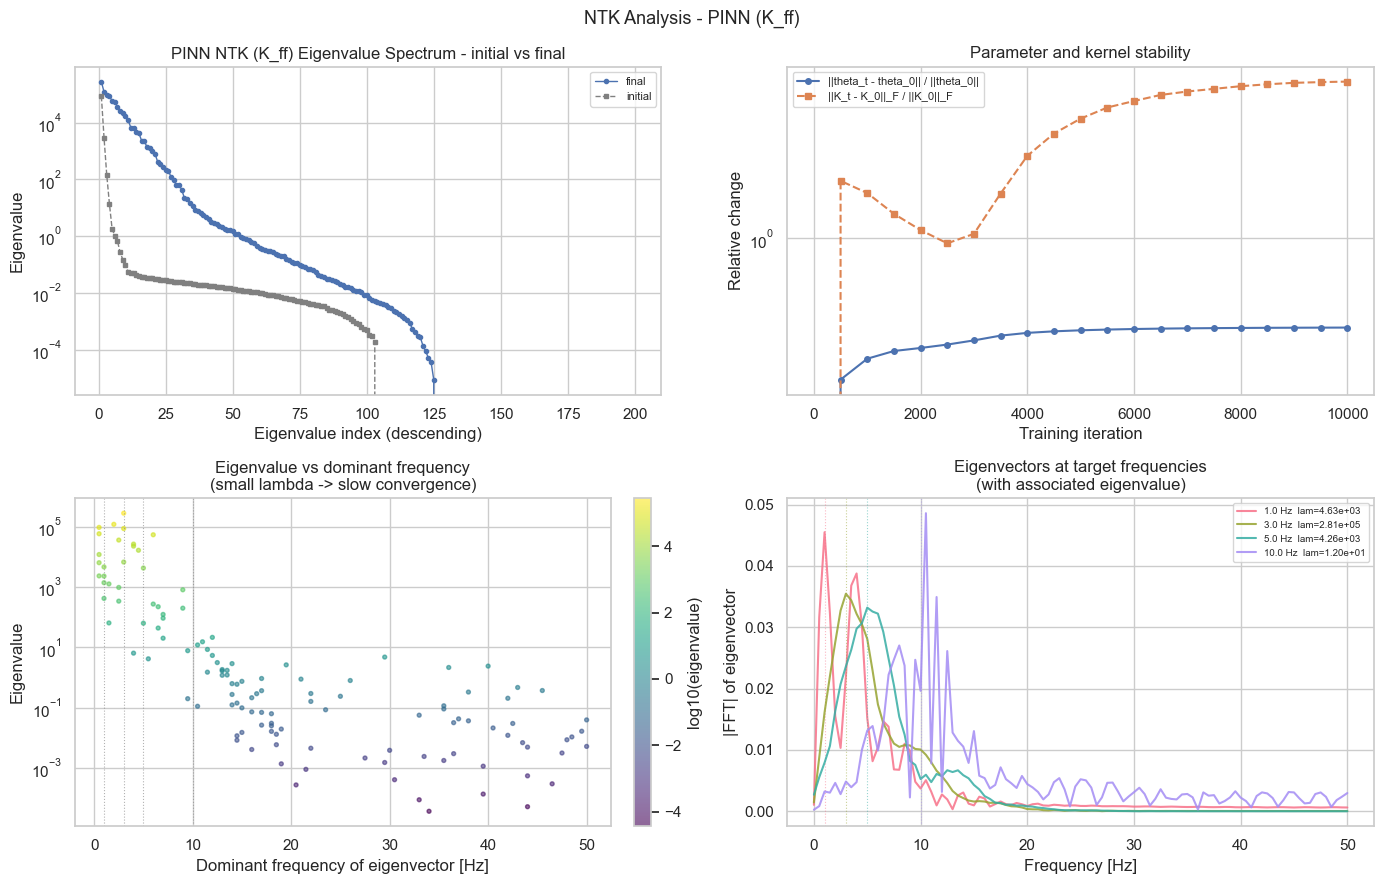

In [ ]:
# NTK analysis - PINN NTK (K_ff) eigendecomposition and stability
transform     = lambda t, z: t * z
t_ntk         = np.asarray(t_eval, dtype=np.float32)
N_ntk         = len(t_ntk)
ntk_subsample = 5

eigenvalues_final, eigenvectors_final = model.ntk_spectrum(
    t_ntk, ode.rhs_torch, transform=transform, device=opt.DEVICE
)



dom_freqs = np.zeros(N_ntk)
for k in range(N_ntk):
    frqs_k, spec_k = compute_fft(eigenvectors_final[:, k], sample_rate)
    dom_freqs[k] = frqs_k[1 + np.argmax(spec_k[1:])] if len(frqs_k) > 1 else frqs_k[np.argmax(spec_k)]

# Evolution across subsampled snapshots
all_snapshots = [(f.iter_num, f.model_state) for f in frames]
sub = all_snapshots[::ntk_subsample]
if all_snapshots[-1] not in sub:
    sub = list(sub) + [all_snapshots[-1]]

saved_state = {k: v.clone() for k, v in model.state_dict().items()}

_, state0 = all_snapshots[0]
model.load_state_dict(state0)
theta_0 = np.concatenate([v.cpu().numpy().ravel() for v in state0.values()])
K_0 = model.ntk(t_ntk, ode.rhs_torch, transform=transform, device=opt.DEVICE)
eigenvalues_init, _ = model.ntk_spectrum(t_ntk, ode.rhs_torch, transform=transform, device=opt.DEVICE)

evo_iters, evo_param, evo_kernel = [], [], []
for it, state in sub:
    model.load_state_dict(state)
    theta_t = np.concatenate([v.cpu().numpy().ravel() for v in state.values()])
    K_t = model.ntk(t_ntk, ode.rhs_torch, transform=transform, device=opt.DEVICE)
    evo_iters.append(it)
    evo_param.append(np.linalg.norm(theta_t - theta_0) / (np.linalg.norm(theta_0) + 1e-30))
    evo_kernel.append(np.linalg.norm(K_t - K_0, "fro") / (np.linalg.norm(K_0, "fro") + 1e-30))

model.load_state_dict(saved_state)
model.eval()

palette_ntk = sns.color_palette("husl", len(opt.freqs))
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("NTK Analysis - PINN (K_ff)", fontsize=13)

ax = axes[0, 0]
idx_arr = np.arange(1, N_ntk + 1)
ax.semilogy(idx_arr, eigenvalues_final, "o-", markersize=3, linewidth=1, label="final")
ax.semilogy(idx_arr, eigenvalues_init,  "s--", markersize=3, linewidth=1, color="gray", label="initial")
ax.set_xlabel("Eigenvalue index (descending)")
ax.set_ylabel("Eigenvalue")
ax.set_title("PINN NTK (K_ff) Eigenvalue Spectrum - initial vs final")
ax.legend(fontsize=8)

ax = axes[0, 1]
ax.plot(evo_iters, evo_param,  "o-",  markersize=4, label="||theta_t - theta_0|| / ||theta_0||")
ax.plot(evo_iters, evo_kernel, "s--", markersize=4, label="||K_t - K_0||_F / ||K_0||_F")
ax.set_yscale("log")
ax.set_xlabel("Training iteration")
ax.set_ylabel("Relative change")
ax.set_title("Parameter and kernel stability")
ax.legend(fontsize=8)

ax = axes[1, 0]
valid_mask = eigenvalues_final > eigenvalues_final.max() * 1e-10
sc = ax.scatter(
    dom_freqs[valid_mask], eigenvalues_final[valid_mask], s=8, alpha=0.6,
    c=np.log10(eigenvalues_final[valid_mask] + 1e-30), cmap="viridis"
)
fig.colorbar(sc, ax=ax, label="log10(eigenvalue)", fraction=0.046, pad=0.04)
for f in opt.freqs:
    ax.axvline(f, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
ax.set_xlabel("Dominant frequency of eigenvector [Hz]")
ax.set_ylabel("Eigenvalue")
ax.set_yscale("log")
ax.set_title("Eigenvalue vs dominant frequency\n(small lambda -> slow convergence)")

ax = axes[1, 1]
used = set()
for f, col in zip(opt.freqs, palette_ntk):
    best_k, best_dist = None, float("inf")
    for k in range(N_ntk):
        if k in used:
            continue
        d = abs(dom_freqs[k] - f)
        if d < best_dist:
            best_dist, best_k = d, k
    if best_k is None:
        continue
    used.add(best_k)
    frqs_k, spec_k = compute_fft(eigenvectors_final[:, best_k], sample_rate)
    ax.plot(frqs_k, spec_k, color=col, alpha=0.85,
            label=f"{f} Hz  lam={eigenvalues_final[best_k]:.2e}")
    ax.axvline(f, color=col, linestyle=":", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("|FFT| of eigenvector")
ax.set_title("Eigenvectors at target frequencies\n(with associated eigenvalue)")
ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "ntk_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

In [30]:
print("\n=== Spectral amplitude at forcing frequencies ===")
print(f"{'Method':<25}", end="")
for f in opt.freqs:
    print(f"  {f} Hz", end="")
print()
for sol, lab in [
    (y_ref,    "Reference (RK45)"),
    (y_picard, f"Picard (k={opt.PICARD_ITERS})"),
    (y_pinn,   "PINN"),
]:
    frqs_s, spec_s = compute_fft(sol[:, 0], sample_rate)
    print(f"{lab:<25}", end="")
    for f in opt.freqs:
        print(f"  {spec_s[np.argmin(np.abs(frqs_s - f))]:.4f}", end="")
    print()


=== Spectral amplitude at forcing frequencies ===
Method                     1.0 Hz  3.0 Hz  5.0 Hz  10.0 Hz
Reference (RK45)           0.1623  0.0548  0.0324  0.0159
Picard (k=20)              0.1622  0.0546  0.0321  0.0154
PINN                       0.1623  0.0544  0.0313  0.0083
